Bài tập 1 (kỹ thuật đọc và xử lý dữ liệu từ file .csv): Cho trước file dữ liệu advertising.csv, hãy hoàn
thành function load_data_from_file() trả về dữ liệu đã được tổ chức (features_X cho input và
sales_Y cho output).

In [1]:
import random

import numpy as np

random.seed(0)  # please do not remove this line
%matplotlib inline

def load_data_from_file(fileName = "../../../data/module4/week3/advertising.csv"):
	data = np.genfromtxt(fileName, dtype = None, delimiter = ',', skip_header = 1)
	features_X = data[:, :3]
	sales_Y = data[:, 3]
	# ****** your code here ******************
	intercept = np.ones((features_X.shape[0], 1))
	
	features_X = np.concatenate((intercept, features_X), axis = 1)

	return features_X, sales_Y


Question 2: Hãy cho biết kết quả của đoạn chương trình sau:

In [2]:
features_X, _ = load_data_from_file()
print(features_X[:5, :])

[[  1.  230.1  37.8  69.2]
 [  1.   44.5  39.3  45.1]
 [  1.   17.2  45.9  69.3]
 [  1.  151.5  41.3  58.5]
 [  1.  180.8  10.8  58.4]]


Question 3: Hãy cho biết kết quả của đoạn chương trình sau:

In [3]:
_, sales_Y = load_data_from_file()
print(sales_Y.shape)

(200,)


Bài tập 2 (kỹ thuật khởi tạo giá trị cho từng gene trong chromosome (individual), tạo ra các

giá trị ngẫu nhiên cho một cá thể (tham số theta của mô hình)): hãy hoàn thiện function cre-
ate_individual(n,bound) để khởi tạo ngẫu nhiên giá trị của n genes (tham số θi) trong chromosome

với giá trị từng gene được khởi tạo [-bound/2, bound/2]

In [4]:
def generate_random_value(bound = 10):
    return (random.random() - 0.5)*bound

def create_individual(n = 4, bound = 10):
	# *************** Your code here *******
	individual = [generate_random_value() for _ in range(n)]
	return individual


individual = create_individual()
print(individual)

[3.444218515250481, 2.5795440294030247, -0.79428419169155, -2.4108324970703663]


Bài tập 3 (kỹ thuật xây dựng fitness function để đánh giá fitness score cho từng chromosome):
hãy hoàn thiện function compute_fitness(individual) để tính fitness values của một chromosome
bằng cách nghịch đảo giá trị của hàm loss theo công thức fitness = 1 / (loss + 1). Hàm com-
pute_fitness(individual) đánh giá độ tốt của một cá thể. Giá trị càng lớn thì cá thể càng tốt.

In [5]:
features_X, sales_Y = load_data_from_file()


def compute_loss(individual):
	theta = np.array(individual)
	y_hat = features_X.dot(theta)
	loss = np.multiply((y_hat - sales_Y), (y_hat - sales_Y)).mean()
	return loss


def compute_fitness(individual):
	loss = compute_loss(individual)
	# ************ your code here ************
	fitness_value = 1 / (loss + 1)

	return fitness_value

In [6]:
features_X, sales_Y = load_data_from_file()
individual = [4.09, 4.82, 3.10, 4.02]
fitness_score = compute_fitness(individual)
print(fitness_score)

1.0185991537088997e-06


Bài tập 4 (kỹ thuật thực hiện crossover giữa 2 chromosomes): hãy hoàn thiện function crossover(individual1,
individual2, crossover_rate = 0.9) để thực hiện crossover giữa 2 individual (chromosome). Bước
này, thực hiện việc lai tạo (trao đổi gen) giữa 2 individual với tỉ lệ crossover_rate

In [7]:
def crossover(individual1, individual2, crossover_rate = 0.9):
	individual1_new = individual1.copy()
	individual2_new = individual2.copy()
	#*************** Your code here **************
	for i in range(len(individual1_new)):
		if random.random() < crossover_rate:
			individual1_new[i], individual2_new[i] = individual2[i], individual1[i]

	# individual1_new = [x * crossover_rate for x in individual1_new]
	# individual2_new = [x * crossover_rate for x in individual2_new]

	return individual1_new, individual2_new

In [8]:
# question 5
individual1 = [4.09, 4.82, 3.10, 4.02]
individual2 = [3.44, 2.57, -0.79, -2.41]
individual1, individual2 = crossover(individual1, individual2, 2.0)
print(" individual1 : ", individual1)
print(" individual2 : ", individual2)

 individual1 :  [3.44, 2.57, -0.79, -2.41]
 individual2 :  [4.09, 4.82, 3.1, 4.02]


Bài tập 5 (kỹ thuật mutation với chromosome): hãy hoàn thiện function mutate(individual, muta-tion_rate = 0.05) để thực hiện việc đột biến cho một cá thể với tỉ lệ đột biến là mutation_rate.

In [9]:
def mutate(individual, mutation_rate = 0.05):
	individual_m = individual.copy()
	# ******** Your code here ******************
	for i in range(len(individual_m)):
		if random.random() < mutation_rate:
			individual_m[i] = generate_random_value()

	return individual_m

Question 6: Hãy cho biết kết quả của đoạn chương trình sau:

In [10]:
before_individual = [4.09, 4.82, 3.10, 4.02]
after_individual = mutate(individual, mutation_rate = 2.0)
print(before_individual == after_individual)


False


Bài tập 6 (khởi tạo population đầu tiên): hãy hoàn thiện function initializePopulation(m) để thực
hiện việc khởi tạo m cá thể (individual, chromosome) cho population.

In [11]:
def initializePopulation(m):
	population = [create_individual() for _ in range(m)]
	return population


Bài tập 7 (Kỹ thuật selection để thực hiện việc chọc lọc tư nhiên, đào thải những cá thể yếu trong
population): hãy hoàn thiện function selection() để thực hiện việc chọn lọc tự nhiên cá thể tốt vào thế
hệ kế tiếp.



In [12]:
def selection(sorted_old_population, m = 100):
	index1 = random.randint(0, m - 1)
	while True:
		index2 = random.randint(0, m - 1)
		if index2 != index1:
			break
	individual_s = sorted_old_population[index1]
	if index2 > index1:
		individual_s = sorted_old_population[index2]
	return individual_s

In [22]:
population = initializePopulation(m=100)
individual_s = selection(population, m = 100)
print(individual_s)

[-2.1489037074635418, 0.09784973536329122, 0.16245420056961168, 1.4208545518410287]


Bài tập 8 (Kỹ thuật tạo ra quần thể (population) mới: Hãy hoàn thiện function create_new_population()
để tạo ra quần thể mới đựa trên các bước selection, crossover và mutation. Lưu ý rằng chúng ta sẽ sử
dụng giải thuât Elitist algorithms để đảm bảo rằng elitism cá thể tốt nhất không bị loại bỏ, bằng cách
chuyển chúng trực tiếp sang thế hệ tiếp theo.

In [13]:
def create_new_population(old_population, elitism = 2, gen = 1):
	m = len(old_population)
	sorted_population = sorted(old_population, key = compute_fitness)
	if gen % 1 == 0:
		print(" Best loss :", compute_loss(sorted_population[m - 1]), " with chromsome : ", sorted_population[m - 1])
	new_populations = []
	while len(new_populations) < m - elitism:
		# selection
		# **************** your code here ****************
		individual_s1 = selection(sorted_population, m)
		individual_s2 = selection(sorted_population, m)
		# crossover
		# **************** your code here ****************
		individual_t1, individual_t2 = crossover(individual_s1, individual_s2)
		# mutation
		# **************** your code here ****************
		new_populations.append(mutate(individual_t1))
		new_populations.append(mutate(individual_t2))
	# copy elitism chromosomes that have best fitness score to the next generation
	for ind in sorted_population[m - elitism:]:
		new_populations.append(ind.copy())

	# **************** your code here ****************

	return new_populations, compute_loss(sorted_population[m - 1])



In [14]:
individual1 = [4.09, 4.82, 3.10, 4.02]
individual2 = [3.44, 2.57, -0.79, -2.41]
old_population = [individual1, individual2]
new_population, _ = create_new_population(old_population, elitism = 2, gen = 1)



 Best loss : 123415.051528805  with chromsome :  [3.44, 2.57, -0.79, -2.41]


Bài tập 9 (All-in-one) Hãy hoàn thiện function run_GA() để tìm tham số θ1, θ2, θ3, θ4 tối ưu sử dụng
giải thuật di truyền.

In [23]:
def run_GA():
	n_generations = 100
	m = 600
	features_X, sales_Y = load_data_from_file()
	population = initializePopulation(m)
	losses_list = []
	for i in range(n_generations):
		# *********** your code here *************
		population, loss = create_new_population(population,  2,  i)
		losses_list.append(loss)
	return losses_list

In [19]:
losses_list = run_GA()

 Best loss : 1876.742850136191  with chromsome :  [-0.06176959558359063, -0.15491709874299708, 2.93663757834178, -0.7273876186411043]
 Best loss : 1876.742850136191  with chromsome :  [-0.06176959558359063, -0.15491709874299708, 2.93663757834178, -0.7273876186411043]
 Best loss : 1640.296649114125  with chromsome :  [-2.5388054370402733, -0.09578647478067359, -1.3573811919083367, 1.8350807178493667]
 Best loss : 1031.0339022496787  with chromsome :  [-0.35588298098301885, 0.054473910723601415, -1.1367166955285746, 0.22650302011670842]
 Best loss : 693.7262701438387  with chromsome :  [2.0512497023035783, -0.018095388007079993, 0.9232104911895855, 0.4287205104661096]
 Best loss : 256.9343430957772  with chromsome :  [-1.4369186113514376, 0.03554392508104298, 1.1080519714452564, -0.21715403184921045]
 Best loss : 256.9343430957772  with chromsome :  [-1.4369186113514376, 0.03554392508104298, 1.1080519714452564, -0.21715403184921045]
 Best loss : 178.84535154706026  with chromsome :  [-3.

Bài tập 10 (Trực quan hoá loss values) Hoàn thiện function visualize_loss()để thể hiện giá trị loss
tốt nhất của cá thể (chromosome) ứng với từng thế hệ (generations) (hình 2)

 Best loss : 1176.9250140386864  with chromsome :  [-3.0203307540024706, 0.26971637053612274, 0.1584067551004975, 0.1125673020207496]
 Best loss : 1176.9250140386864  with chromsome :  [-3.0203307540024706, 0.26971637053612274, 0.1584067551004975, 0.1125673020207496]
 Best loss : 1154.0516329544266  with chromsome :  [-3.4225726001766454, 0.26971637053612274, 0.1584067551004975, 0.1125673020207496]
 Best loss : 779.1534526013661  with chromsome :  [-2.129044635374362, -0.09804220393993424, 0.1584067551004975, 0.1125673020207496]
 Best loss : 98.11184738749608  with chromsome :  [-2.287474964808396, 0.1358097652553636, -0.36941631695684984, 0.1125673020207496]
 Best loss : 98.11184738749608  with chromsome :  [-2.287474964808396, 0.1358097652553636, -0.36941631695684984, 0.1125673020207496]
 Best loss : 98.11184738749608  with chromsome :  [-2.287474964808396, 0.1358097652553636, -0.36941631695684984, 0.1125673020207496]
 Best loss : 63.097420097377146  with chromsome :  [-3.02033075400

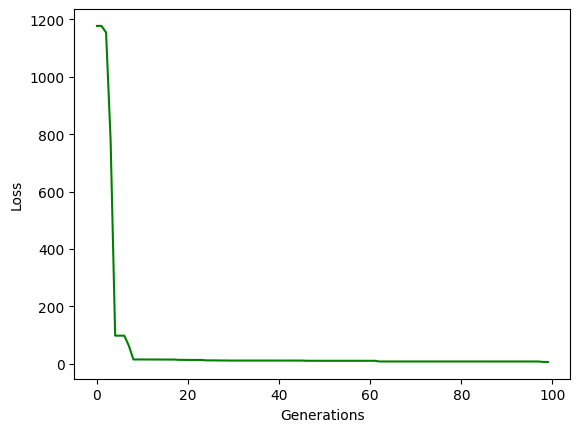

In [24]:
import matplotlib.pyplot as plt


def visualize_loss(losses_list):
	# *********** your code here *************
	plt.plot(losses_list,c="green")
	plt.xlabel('Generations')
	plt.ylabel('Loss')
	plt.show()

losses_list = run_GA()
visualize_loss(losses_list)

[4.0446942529053835, 0.16645857035473943, 1.533167484139576, -1.7375655528497191]


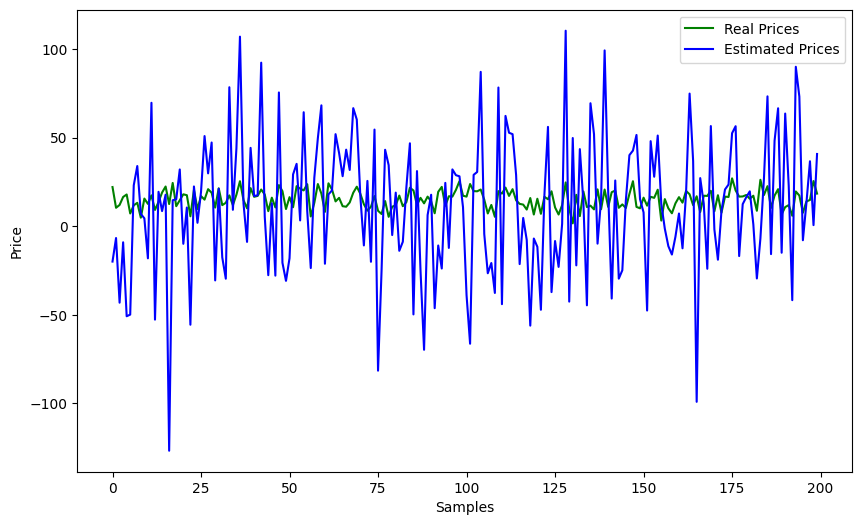

In [25]:
def visualize_predict_gt():
  # visualization of ground truth and predict value
  sorted_population = sorted(population, key=compute_fitness)
  print(sorted_population[-1])
  theta = np.array(sorted_population[-1])

  estimated_prices = []
  for feature in features_X:
      estimated_price = sum(c*x for x, c in zip(feature, theta))
      estimated_prices.append(estimated_price)

  fig, ax = plt.subplots(figsize=(10, 6))
  plt.xlabel('Samples')
  plt.ylabel('Price')
  plt.plot(sales_Y, c='green', label='Real Prices')
  plt.plot(estimated_prices, c='blue', label='Estimated Prices')
  plt.legend()
  plt.show()

visualize_predict_gt()

[4.0446942529053835, 0.16645857035473943, 1.533167484139576, -1.7375655528497191]


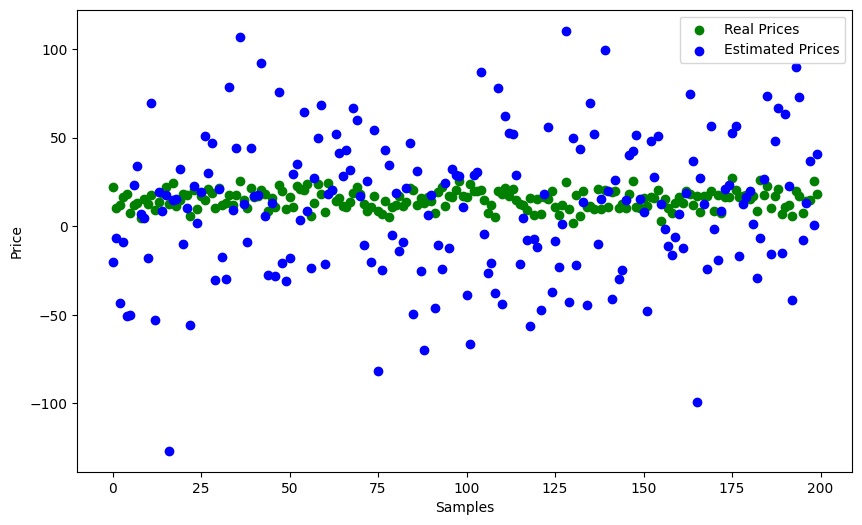

In [26]:
# visualization of ground truth and predict value
sorted_population = sorted(population, key=compute_fitness)
print(sorted_population[-1])
theta = np.array(sorted_population[-1])

estimated_prices = []
samples = [i for i in range(len(features_X))]
for feature in features_X:
    estimated_price = sum(c*x for x, c in zip(feature, theta))
    estimated_prices.append(estimated_price)
fig, ax = plt.subplots(figsize=(10, 6))
# plt.plot(prices, c='green')
# plt.plot(estimated_prices, c='red')
plt.xlabel('Samples')
plt.ylabel('Price')
plt.scatter(samples, sales_Y, c='green', label='Real Prices')
plt.scatter(samples, estimated_prices, c='blue', label='Estimated Prices')
plt.legend()
plt.show()